# Análisis univariante

Importamos las bibliotecas necesarias para poder analizar y visualizar los datos de manera correcta.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_data = pd.read_csv("../data/develop_dataset_2025_limpio.csv", index_col=0)

In [2]:
# 1. Tipificar los datos

numeric_cols = df_data.select_dtypes(include="number").columns
categorical_cols = df_data.select_dtypes(include=["object", "string", "category"]).columns

print("Variables numéricas:")
print(numeric_cols)

print("\nVariables categóricas:")
print(categorical_cols)

Variables numéricas:
Index(['ConvertedCompYearly', 'WorkExp', 'YearsCode', 'JobSat'], dtype='str')

Variables categóricas:
Index(['Age', 'EdLevel', 'Employment', 'AISelect', 'Industry', 'Country',
       'DevType'],
      dtype='str')


En este paso se han tipificado las variables del dataset según su tipo de dato. Se identifican cuatro variables numéricas: `ConvertedCompYearly`, `WorkExp`, `YearsCode` y `JobSat`, que permiten calcular medidas estadísticas como media, mediana, dispersión y rangos.

Por otro lado, se identifican siete variables categóricas: `Age`, `EdLevel`, `Employment`, `AISelect`, `Industry`, `Country` y `DevType`. Estas variables representan categorías o grupos, por lo que se analizarán mediante frecuencias, porcentajes y gráficos de barras.

La variable `Age` se considera categórica porque está expresada en rangos de edad y no como una edad numérica exacta.

In [3]:
# 2. Tendencia central de variables numéricas
df_data[numeric_cols].agg(["mean", "median", "min", "max"])


,ConvertedCompYearly,WorkExp,YearsCode,JobSat
mean,1.019995e+05,12.427915,15.668007,7.229605
median,8.000000e+04,10.000000,13.000000,8.000000
min,1.000000e+00,1.000000,1.000000,0.000000
max,4.706124e+06,50.000000,60.000000,10.000000


In [4]:
# Revisar valores extremos en salario
df_data.sort_values("ConvertedCompYearly", ascending=False)[
    ["ConvertedCompYearly", "Country", "DevType", "WorkExp", "YearsCode"]
].head(10)

,ConvertedCompYearly,Country,DevType,WorkExp,YearsCode
14873,4706124.0,UK and Ireland,Data engineer,8.0,16.0
5410,2346000.0,USA,Data scientist,11.0,18.0
31876,1555205.0,Denmark,AI/ML engineer,9.0,11.0
45087,900000.0,USA,AI/ML engineer,8.0,18.0
27376,878500.0,USA,Data analyst,10.0,10.0
20592,850000.0,USA,Data engineer,16.0,20.0
17898,725000.0,USA,Data engineer,28.0,30.0
19083,650000.0,USA,Data engineer,8.0,15.0
37366,583667.0,Canada,AI developer,5.0,8.0
10373,570000.0,USA,Data engineer,13.0,18.0


In [5]:
# Revisar valores extremos en YearsCode
df_data.sort_values("YearsCode", ascending=False)[
    ["YearsCode", "Age", "WorkExp", "DevType", "Country"]
].head(10)

,YearsCode,Age,WorkExp,DevType,Country
17793,60.0,65 years or older,25.0,AI/ML engineer,USA
2846,58.0,65 years or older,20.0,Applied scientist,USA
40129,57.0,65 years or older,47.0,Data scientist,UK and Ireland
41415,55.0,65 years or older,40.0,Data scientist,USA
35208,53.0,55-64 years old,43.0,Data scientist,USA
16716,52.0,65 years or older,45.0,Applied scientist,Canada
39942,50.0,65 years or older,43.0,Applied scientist,USA
5273,50.0,65 years or older,45.0,AI/ML engineer,USA
9177,49.0,65 years or older,40.0,Data scientist,USA
22901,48.0,55-64 years old,42.0,Applied scientist,USA


En esta primera revisión se observan posibles valores anómalos en algunas variables numéricas. En `ConvertedCompYearly`,  el máximo de 4.706.124 parece un extremo para una compensación anual, por lo que se analizará posteriormente como posibles outliers. También destacaba `YearsCode`, con un máximo de 100 años, valor que parece poco realista y requiere revisión, la cual se ha realizado en otro notebook.

In [6]:
# Limpieza inicial previa al análisis univariante

# df_data = df_data.copy()

# # Corregir valores claramente anómalos en YearsCode
# df_data.loc[df_data["YearsCode"] == 100, "YearsCode"] = pd.NA

# # Comprobar el resultado después de la limpieza
# df_data["YearsCode"].describe()

# Se realiza en el notebook_eda_inicial, para no tener que repetir constantemente

Tras revisar la variable `YearsCode`, se detectaron dos registros con un valor de 100 años programando, incompatibles con el rango de edad declarado. Estos valores se sustituyeron por nulos, manteniendo el resto de información de los registros.

Después de la limpieza, la variable presenta 1741 valores válidos, una media de 15,67 años, una mediana de 13 años y un máximo de 60 años, valores más coherentes para el análisis.

In [7]:
# 3. Tendencia central de variables categóricas
# En categóricas usamos la moda: el valor más frecuente

for col in categorical_cols:
    print(f"\nVariable: {col}")
    print("Moda:")
    print(df_data[col].mode()[0])


Variable: Age
Moda:
25-34 years old

Variable: EdLevel
Moda:
Master

Variable: Employment
Moda:
Employed

Variable: AISelect
Moda:
Yes

Variable: Industry
Moda:
Software Development

Variable: Country
Moda:
USA

Variable: DevType
Moda:
Data engineer


En las variables categóricas, la medida de tendencia central utilizada es la moda, ya que representa la categoría más frecuente de cada variable.

Los resultados muestran que el perfil más habitual del dataset corresponde a personas de 25-34 años, con nivel educativo de máster, empleadas, que han respondido afirmativamente a `AISelect`, pertenecientes principalmente a la industria de desarrollo de software, procedentes de Estados Unidos y con perfil profesional de Data engineer.


Variable categórica: Age
Age
25-34 years old      686
35-44 years old      513
45-54 years old      249
18-24 years old      166
55-64 years old      100
65 years or older     26
Prefer not to say      1
Name: count, dtype: int64

Porcentajes:
Age
25-34 years old      39.40
35-44 years old      29.47
45-54 years old      14.30
18-24 years old       9.53
55-64 years old       5.74
65 years or older     1.49
Prefer not to say     0.06
Name: proportion, dtype: float64


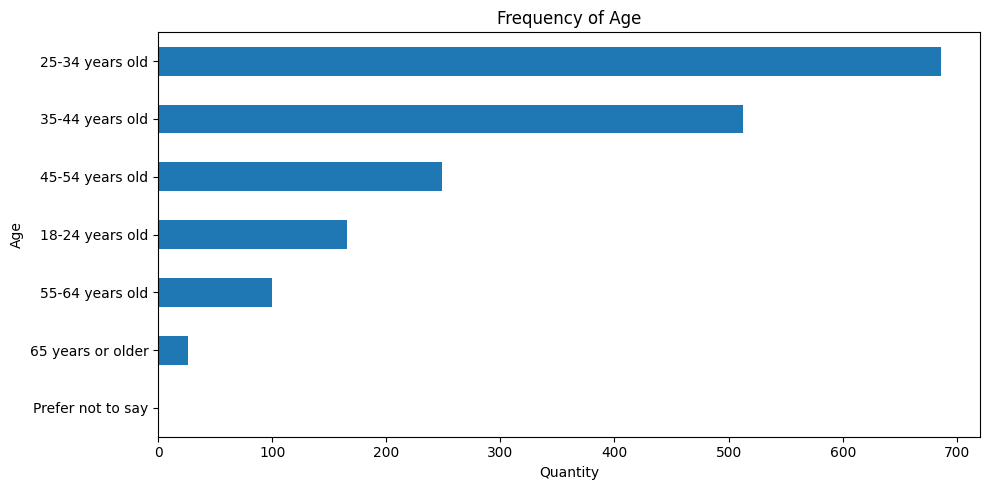


Variable categórica: EdLevel
EdLevel
Master                     715
Bachelor                   553
Professional               275
Some College               101
Secondary                   46
Associate                   29
Other (please specify):     13
Primary                      9
Name: count, dtype: int64

Porcentajes:
EdLevel
Master                     41.07
Bachelor                   31.76
Professional               15.80
Some College                5.80
Secondary                   2.64
Associate                   1.67
Other (please specify):     0.75
Primary                     0.52
Name: proportion, dtype: float64


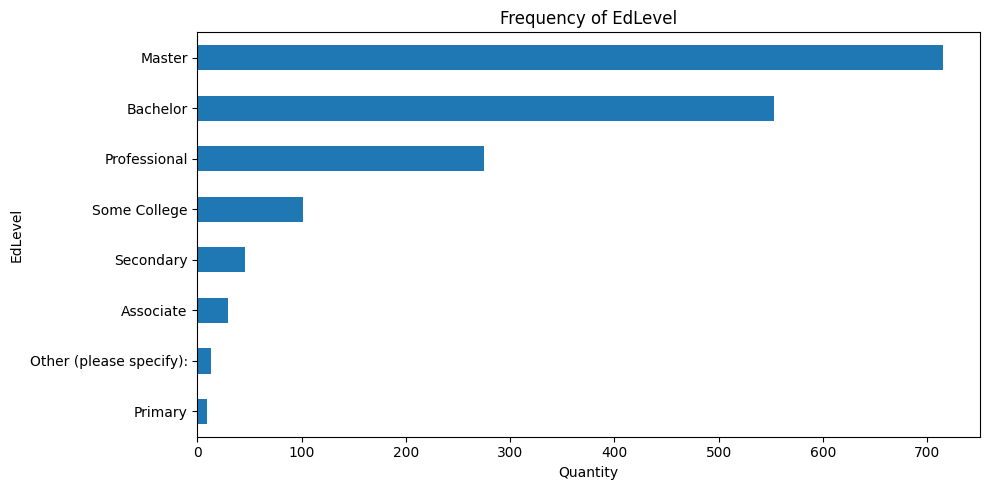


Variable categórica: Employment
Employment
Employed               1468
Freelancer              193
Not employed             37
Student                  29
Retired                  12
I prefer not to say       2
Name: count, dtype: int64

Porcentajes:
Employment
Employed               84.32
Freelancer             11.09
Not employed            2.13
Student                 1.67
Retired                 0.69
I prefer not to say     0.11
Name: proportion, dtype: float64


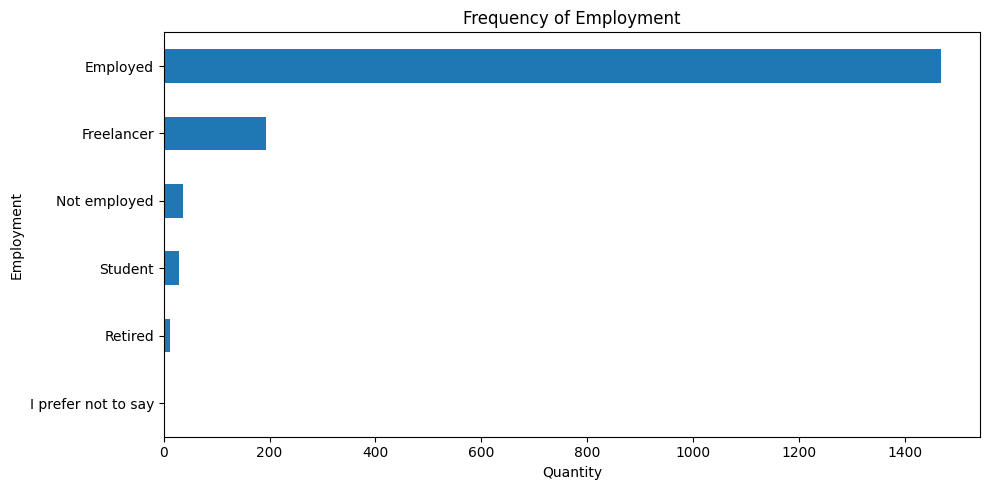


Variable categórica: AISelect
AISelect
Yes    1360
No      308
NaN      73
Name: count, dtype: int64

Porcentajes:
AISelect
Yes    78.12
No     17.69
NaN     4.19
Name: proportion, dtype: float64


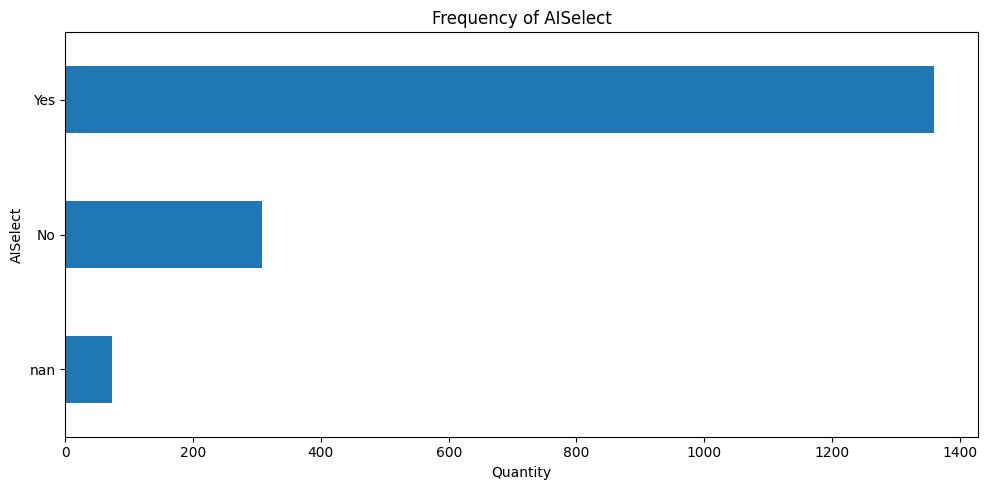


Variable categórica: Industry
Industry
Software Development                          582
Other:                                        198
Healthcare                                    125
Government                                    114
Banking/Financial Services                     95
Internet, Telecomm or Information Services     94
Manufacturing                                  75
Fintech                                        75
Energy                                         73
Retail and Consumer Services                   62
Transportation, or Supply Chain                61
Media & Advertising Services                   57
Computer Systems Design and Services           50
Higher Education                               43
Insurance                                      37
Name: count, dtype: int64

Porcentajes:
Industry
Software Development                          33.43
Other:                                        11.37
Healthcare                                     7.18
Gover

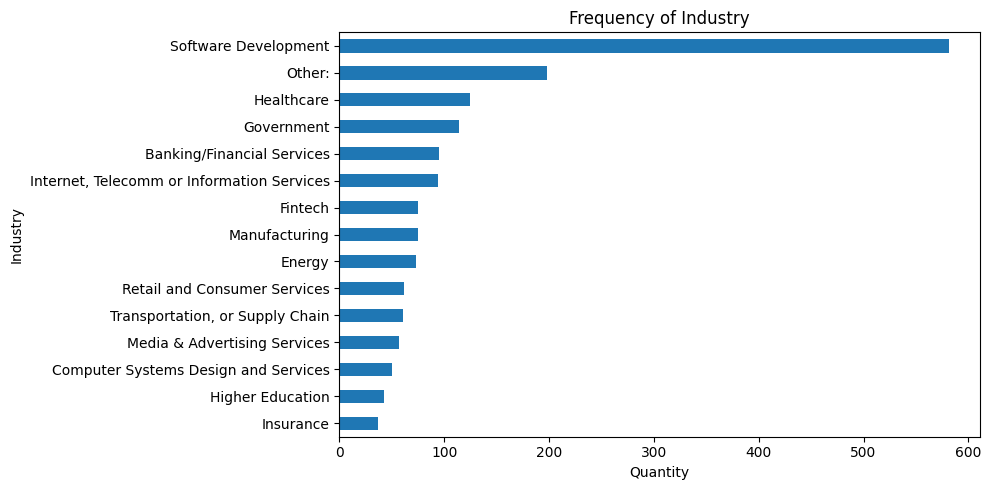


Variable categórica: Country
Country
USA               444
Germany           137
UK and Ireland    112
India              91
France             89
                 ... 
Iceland             1
Ghana               1
Saudi Arabia        1
Moldova             1
Paraguay            1
Name: count, Length: 104, dtype: int64

Porcentajes:
Country
USA               25.50
Germany            7.87
UK and Ireland     6.43
India              5.23
France             5.11
                  ...  
Iceland            0.06
Ghana              0.06
Saudi Arabia       0.06
Moldova            0.06
Paraguay           0.06
Name: proportion, Length: 104, dtype: float64


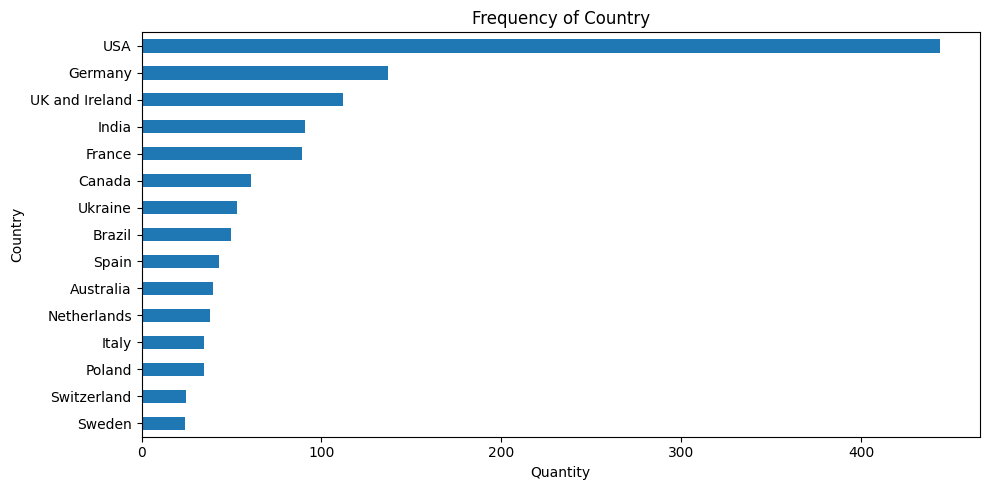


Variable categórica: DevType
DevType
Data engineer             487
AI/ML engineer            351
Data scientist            345
Data analyst              184
Applied scientist         162
AI developer              113
Database administrator     99
Name: count, dtype: int64

Porcentajes:
DevType
Data engineer             27.97
AI/ML engineer            20.16
Data scientist            19.82
Data analyst              10.57
Applied scientist          9.30
AI developer               6.49
Database administrator     5.69
Name: proportion, dtype: float64


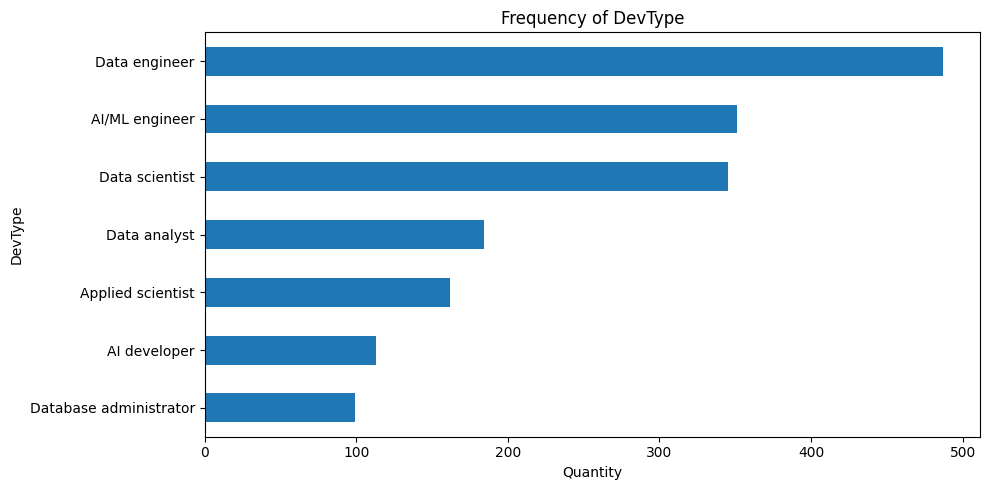

In [8]:
# 4. Frecuencias de variables categóricas

for col in categorical_cols:
    frecuencias = df_data[col].value_counts(dropna=False)
    porcentajes = df_data[col].value_counts(normalize=True, dropna=False) * 100

    print(f"\nVariable categórica: {col}")
    print(frecuencias)
    print("\nPorcentajes:")
    print(porcentajes.round(2))

    plt.figure(figsize=(10, 5))
    frecuencias.head(15).sort_values().plot(kind="barh")
    plt.title(f"Frequency of {col}")
    plt.xlabel("Quantity")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

En el análisis de frecuencias de las variables categóricas se observa que la muestra está formada principalmente por personas de 25 a 44 años, que representan cerca del 69% del total. También destaca el alto nivel educativo de los encuestados, ya que más del 70% cuenta con estudios de máster o grado universitario.

En cuanto a la situación laboral, la mayoría de los registros corresponden a personas empleadas, con un 84,32%. Además, el 78,12% respondió afirmativamente en la variable `AISelect`, lo que indica una presencia elevada de perfiles relacionados con el uso o selección de inteligencia artificial.

Respecto a la industria, predomina `Software Development`, con un 33,43%. A nivel geográfico, Estados Unidos es el país más representado, con un 25,50%, aunque el dataset incluye participantes de 104 países. Finalmente, los perfiles profesionales más frecuentes son `Data engineer`, `AI/ML engineer` y `Data scientist`.

In [9]:
# 5. Medidas de posición y rangos de variables numéricas

df_data[numeric_cols].describe()

,ConvertedCompYearly,WorkExp,YearsCode,JobSat
count,1.741000e+03,1741.000000,1741.000000,1189.000000
mean,1.019995e+05,12.427915,15.668007,7.229605
std,1.558536e+05,9.870256,10.498279,1.953224
min,1.000000e+00,1.000000,1.000000,0.000000
25%,4.095800e+04,5.000000,8.000000,6.000000
50%,8.000000e+04,10.000000,13.000000,8.000000
75%,1.276770e+05,17.000000,20.000000,8.000000
max,4.706124e+06,50.000000,60.000000,10.000000


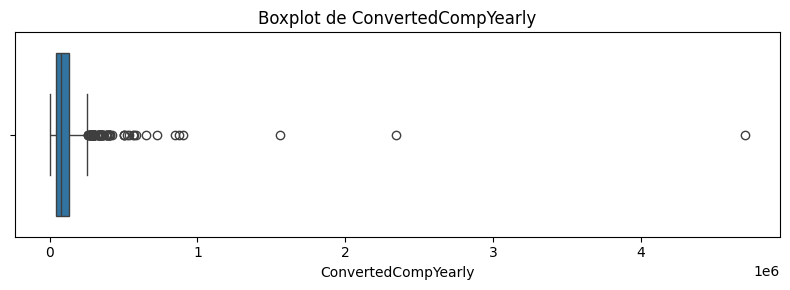

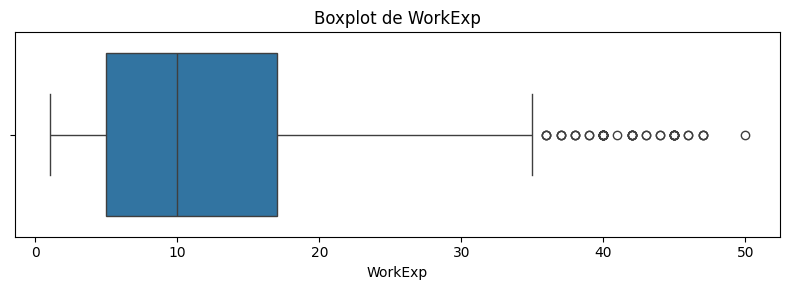

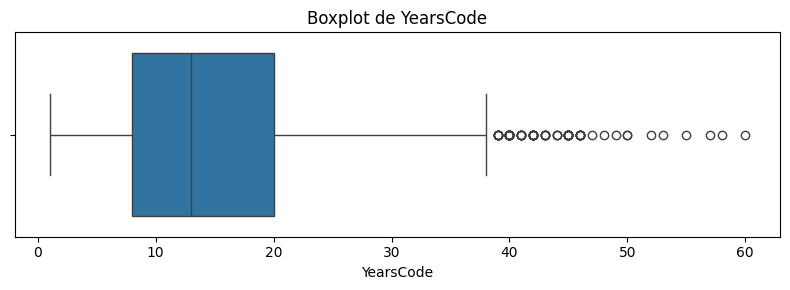

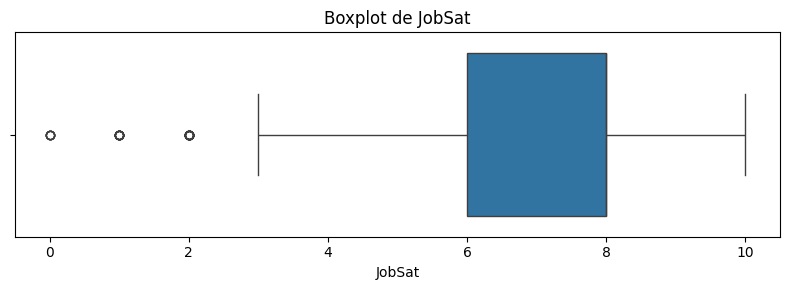

In [10]:
# 6. Gráficos de caja para variables numéricas

numeric_cols_clean = df_data.select_dtypes(include="number").columns

for col in numeric_cols_clean:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_data[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Los gráficos de caja muestran diferencias importantes entre las variables numéricas. `ConvertedCompYearly` presenta una fuerte asimetría positiva, con varios valores atípicos altos que pueden influir en la media. `WorkExp` concentra la mayoría de observaciones entre 5 y 17 años, aunque aparecen valores elevados como outliers estadísticos.

En `YearsCode`, tras eliminar los valores anómalos de 100 años, la distribución resulta más coherente. La mayoría de registros se sitúa entre 8 y 20 años programando, aunque existen valores altos entre 40 y 60 años que pueden ser plausibles en perfiles de mayor edad. Por último, `JobSat` se concentra en valores altos de satisfacción, principalmente entre 6 y 8, mientras que los valores bajos aparecen como outliers pero son válidos dentro de la escala de 0 a 10.

In [11]:
# 7. Medidas de dispersión de variables numéricas

numeric_cols_clean = df_data.select_dtypes(include="number").columns

dispersion = df_data[numeric_cols_clean].agg(["std", "var", "min", "max"])

# Rango = máximo - mínimo
rango = df_data[numeric_cols_clean].max() - df_data[numeric_cols_clean].min()
dispersion.loc["range"] = rango

dispersion

,ConvertedCompYearly,WorkExp,YearsCode,JobSat
std,1.558536e+05,9.870256,10.498279,1.953224
var,2.429035e+10,97.421956,110.213855,3.815082
min,1.000000e+00,1.000000,1.000000,0.000000
max,4.706124e+06,50.000000,60.000000,10.000000
range,4.706123e+06,49.000000,59.000000,10.000000


Las medidas de dispersión muestran una variabilidad muy elevada en `ConvertedCompYearly`, con una desviación estándar de aproximadamente 155.789 y un rango de más de 4,7 millones. Esto confirma la presencia de valores extremos en la compensación anual, por lo que esta variable requiere una revisión más detallada en el análisis de outliers.

En `WorkExp` y `YearsCode` también existe dispersión, aunque dentro de rangos más interpretables. `WorkExp` varía entre 1 y 50 años, mientras que `YearsCode`, tras la limpieza inicial, varía entre 1 y 60 años. Por último, `JobSat` presenta un rango de 0 a 10, coherente con una escala de satisfacción laboral, y una desviación estándar moderada.

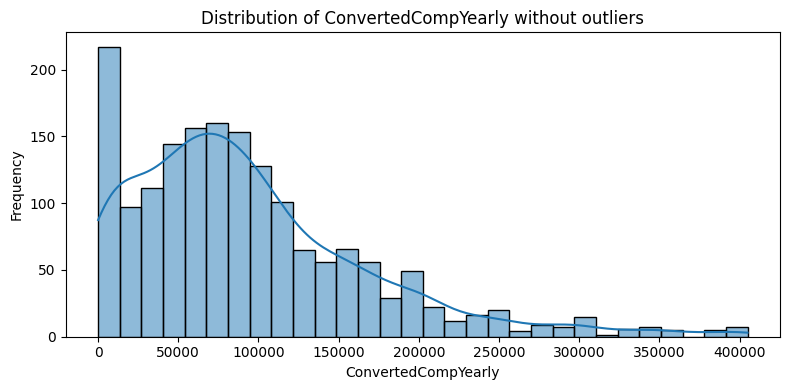

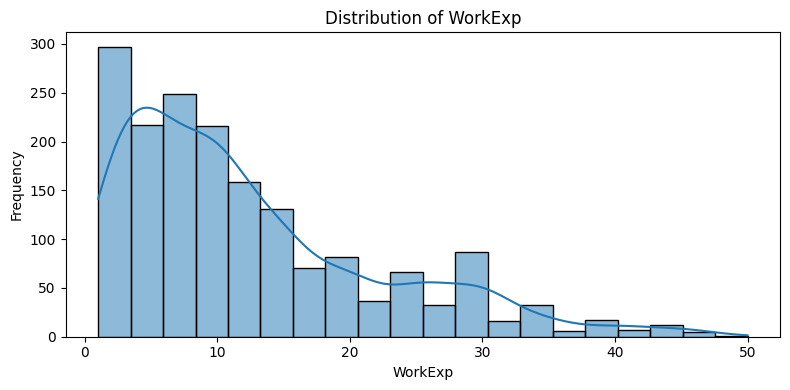

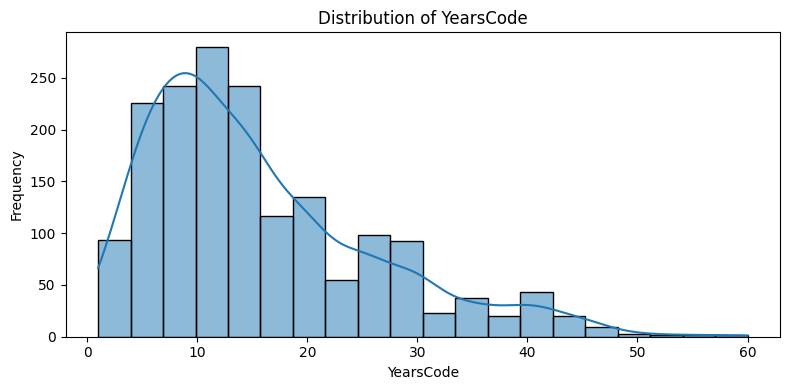

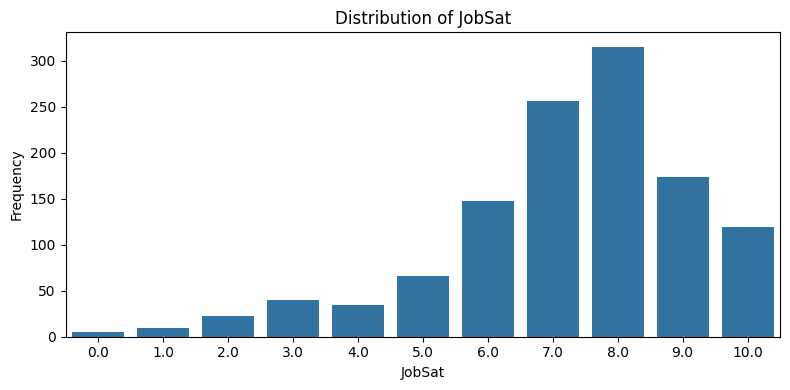

In [12]:
# 8. Distribuciones de variables numéricas
# Versión más legible

for col in numeric_cols_clean:
    plt.figure(figsize=(8, 4))
    
    data = df_data[col].dropna()
    
    if col == "ConvertedCompYearly":
        # Quitamos el 5% más alto para que los valores extremos no aplasten el gráfico
        data = data[data <= data.quantile(0.99)]
        sns.histplot(data, kde=True, bins=30)
        plt.title(f"Distribution of {col} without outliers")
    
    elif col == "JobSat":
        # JobSat es una escala de 0 a 10, mejor contar cada valor
        sns.countplot(x=data)
        plt.title(f"Distribution of {col}")
    
    else:
        sns.histplot(data, kde=True, bins=20)
        plt.title(f"Distribution of {col}")
    
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

Los histogramas muestran que `ConvertedCompYearly` tiene una distribución fuertemente asimétrica hacia la derecha, con la mayoría de salarios concentrados en rangos bajos o medios y algunos valores extremadamente altos. Por este motivo, se añade una visualización en escala logarítmica para interpretar mejor su distribución.

En `WorkExp`, la mayor parte de los registros se concentra entre los primeros años de experiencia y aproximadamente los 15 años, aunque existe una cola hacia valores más altos. `YearsCode` presenta un comportamiento similar, con mayor concentración entre 5 y 20 años programando y algunos valores elevados hasta 60 años.

Por último, `JobSat` se concentra principalmente en valores altos, especialmente entre 7 y 8, lo que sugiere una satisfacción laboral generalmente positiva dentro de la muestra.

In [13]:
# 9. Análisis de anomalías/outliers usando IQR

for col in numeric_cols_clean:
    Q1 = df_data[col].quantile(0.25)
    Q3 = df_data[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_data[
        (df_data[col] < limite_inferior) | 
        (df_data[col] > limite_superior)
    ]

    print(f"\nVariable: {col}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")
    print(f"Número de outliers: {outliers.shape[0]}")
    print(f"Porcentaje de outliers: {round(outliers.shape[0] / df_data.shape[0] * 100, 2)}%")


Variable: ConvertedCompYearly
Límite inferior: -89120.5
Límite superior: 257755.5
Número de outliers: 83
Porcentaje de outliers: 4.77%

Variable: WorkExp
Límite inferior: -13.0
Límite superior: 35.0
Número de outliers: 48
Porcentaje de outliers: 2.76%

Variable: YearsCode
Límite inferior: -10.0
Límite superior: 38.0
Número de outliers: 88
Porcentaje de outliers: 5.05%

Variable: JobSat
Límite inferior: 3.0
Límite superior: 11.0
Número de outliers: 37
Porcentaje de outliers: 2.13%


El análisis de outliers mediante el método IQR confirma la presencia de valores atípicos en todas las variables numéricas. En `ConvertedCompYearly`, se detectan 83 outliers, equivalentes al 4,77% del dataset, correspondientes a compensaciones anuales superiores a 257.755,5 Estos valores explican la fuerte asimetría observada en histogramas y boxplots.

En `WorkExp`, se identifican 48 outliers por encima de 35 años de experiencia, mientras que en `YearsCode` se detectan 88 outliers por encima de 38 años programando. Estos casos no tienen por qué ser errores, ya que pueden corresponder a perfiles profesionales muy senior.

Por último, en `JobSat` se detectan 37 outliers, equivalentes al 2,13%, correspondientes a valores inferiores a 3. Dado que la variable está definida en una escala de 0 a 10, estos valores se consideran válidos y representan niveles bajos de satisfacción laboral.

In [14]:
# Valores nulos por variable

nulos = df_data.isnull().sum()
porcentaje_nulos = df_data.isnull().mean() * 100

missing_values = pd.DataFrame({
    "nulos": nulos,
    "porcentaje_nulos": porcentaje_nulos.round(2)
})

missing_values[missing_values["nulos"] > 0].sort_values("porcentaje_nulos", ascending=False)

,nulos,porcentaje_nulos
JobSat,552,31.71
AISelect,73,4.19


In [15]:
# Resumen completo de variables numéricas

resumen_numericas = df_data[numeric_cols_clean].agg([
    "count", "mean", "median", "std", "min", "max"
]).T

resumen_numericas["range"] = resumen_numericas["max"] - resumen_numericas["min"]

resumen_numericas

,count,mean,median,std,min,max,range
ConvertedCompYearly,1741.0,101999.477312,80000.0,155853.627327,1.0,4706124.0,4706123.0
WorkExp,1741.0,12.427915,10.0,9.870256,1.0,50.0,49.0
YearsCode,1741.0,15.668007,13.0,10.498279,1.0,60.0,59.0
JobSat,1189.0,7.229605,8.0,1.953224,0.0,10.0,10.0


El resumen numérico muestra que `ConvertedCompYearly` presenta una gran dispersión, con una media de 101.907,74 y una mediana de 80.000. La diferencia entre ambas medidas, junto con un rango muy amplio, confirma la presencia de valores extremos altos en la compensación anual.

En `WorkExp`, la media es de 12,42 años y la mediana de 10 años, lo que indica una muestra con experiencia laboral media, aunque con presencia de perfiles muy senior. En `YearsCode`, tras la limpieza inicial, se obtienen 1741 valores válidos, con una media de 15,67 años y un máximo de 60 años.

Por último, `JobSat` presenta 1190 valores válidos, debido a la existencia de valores nulos. Su media de 7,23 y mediana de 8 indican una satisfacción laboral generalmente alta entre las personas que respondieron esta variable.

### Conclusión final del análisis univariante

El análisis univariante muestra que el dataset está compuesto principalmente por perfiles profesionales vinculados al ámbito de datos e inteligencia artificial. Predominan las personas de entre 25 y 44 años, que representan cerca del 69% de la muestra, con un nivel educativo elevado, especialmente máster y grado universitario. Además, la mayoría de los registros corresponden a personas empleadas y el país más representado es Estados Unidos.

En las variables categóricas destaca que el 78,12% de los registros válidos respondió afirmativamente en `AISelect`, lo que indica una fuerte presencia de perfiles relacionados con el uso o selección de inteligencia artificial. También se observa que los perfiles profesionales más frecuentes son `Data engineer`, `AI/ML engineer` y `Data scientist`.

En cuanto a las variables numéricas, `ConvertedCompYearly` presenta una gran dispersión y una distribución fuertemente asimétrica hacia la derecha. La media salarial es superior a la mediana, lo que confirma que existen salarios muy altos que elevan el promedio. Esta variable contiene varios valores atípicos y debe interpretarse con cautela en análisis posteriores.

Las variables `WorkExp` y `YearsCode` muestran distribuciones también sesgadas hacia la derecha, con mayoría de perfiles en rangos medios de experiencia y algunos perfiles muy senior. Durante la limpieza inicial se detectaron dos valores anómalos de 100 años programando en `YearsCode`, que fueron sustituidos por valores nulos, dejando un máximo más coherente de 60 años.

Por último, `JobSat` presenta una satisfacción laboral generalmente alta, con media de 7,23 y mediana de 8. Sin embargo, esta variable tiene un 31,71% de valores nulos, por lo que sus resultados deben interpretarse con prudencia. En conjunto, el análisis univariante permite identificar la estructura general del dataset, sus variables más relevantes, la presencia de valores extremos y algunas limitaciones importantes de calidad de datos.